In [8]:
# 自作モジュールへの変更を自動的にリロードするためのおまじない
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import lib.S2Z as stoz
import lib.Z_model as zmodel
import lib.Useful as usf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


共振周波数 10110000.0
s11の絶対値 0.04993906851709224
リアクタンス -3.083490670061694
レジスタンス 46.30589874878164


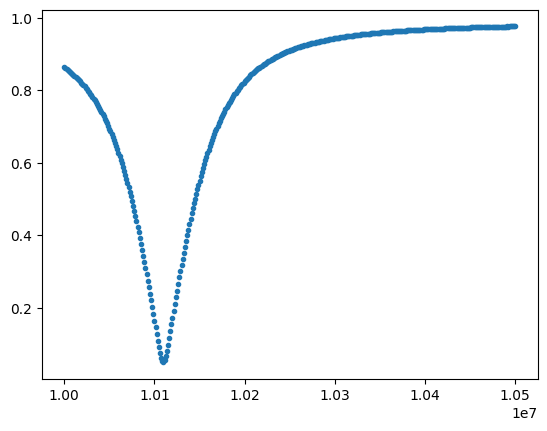

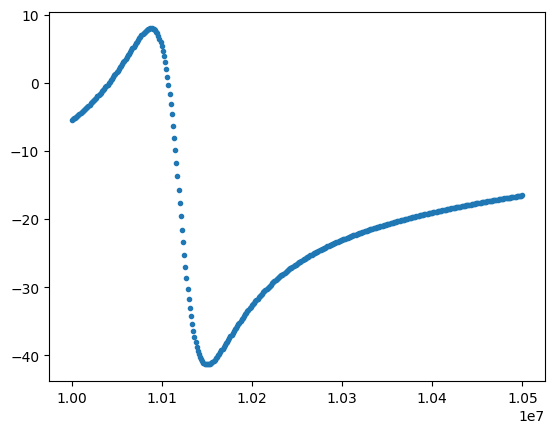

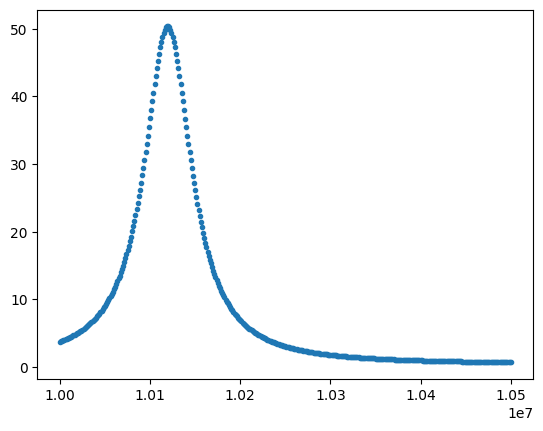

<Figure size 640x480 with 0 Axes>

In [9]:

data = np.loadtxt("../data/today's_best_performance_20260502.s1p", delimiter=" ")
freq, Z = stoz.direct(data)
s = np.abs(data[:, 1] + 1j * data[:, 2])
plt.plot(freq, s, ".")
plt.figure()

plt.plot(freq, Z.imag, ".")
plt.figure()

plt.plot(freq, Z.real, ".")
plt.figure()

print("共振周波数", float(freq[np.argmin(s)]))
print("s11の絶対値",float(s[np.argmin(s)]))
print("リアクタンス",float(Z.imag[np.argmin(s)]))
print("レジスタンス",float(Z.real[np.argmin(s)]))



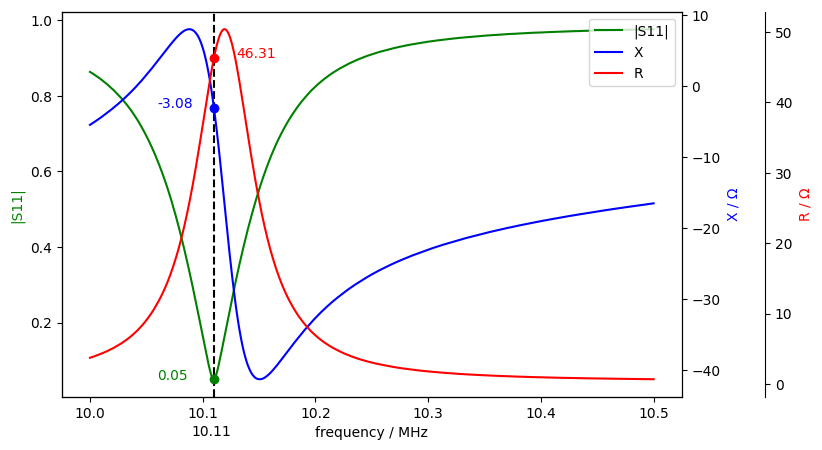

In [10]:
#調整した時のNanoVNA

# 例データ
f=freq* 10**(-6)

# 基本の軸
fig, ax1 = plt.subplots(figsize=(8,5))

# 2つ目・3つ目の縦軸
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# 3つ目の軸をさらに右へずらす
ax3.spines["right"].set_position(("outward", 60))

# プロット
p1 = ax1.plot(f, s, label="|S11|", color="green")
p2 = ax2.plot(f, Z.imag, label="X", color="blue")
p3 = ax3.plot(f, Z.real, label="R",color="red")

# ラベル
ax1.set_xlabel("frequency / MHz")

ax1.set_ylabel("|S11|", color="green")
ax2.set_ylabel("X / Ω", color="blue")
ax3.set_ylabel("R / Ω",color="red")

ax1.axvline(x=float(f[np.argmin(s)]), linestyle="--",color="black")

ax1.plot(float(f[np.argmin(s)]), float(s[np.argmin(s)]), "o", color="green")
ax2.plot(float(f[np.argmin(s)]), float(Z.imag[np.argmin(s)]), "o", color="blue")
ax3.plot(float(f[np.argmin(s)]), float(Z.real[np.argmin(s)]), "o", color="red")
ax1.text(float(f[np.argmin(s)])-0.05, float(s[np.argmin(s)]), f"{float(s[np.argmin(s)]):.2f}", color="green")
ax2.text(float(f[np.argmin(s)])-0.05, float(Z.imag[np.argmin(s)]), f"{float(Z.imag[np.argmin(s)]):.2f}", color="blue")
ax3.text(float(f[np.argmin(s)])+0.02, float(Z.real[np.argmin(s)]), f"{float(Z.real[np.argmin(s)]):.2f}", color="red")
ax1.text(float(f[np.argmin(s)])-0.02, -0.1, f"{float(f[np.argmin(s)]):.2f}", color="black")



# 凡例まとめ
lines = p1 + p2 + p3
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels,loc="upper right")

plt.show()

<Figure size 640x480 with 0 Axes>

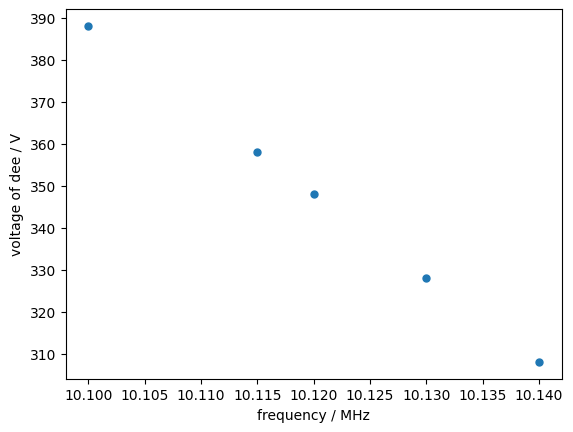

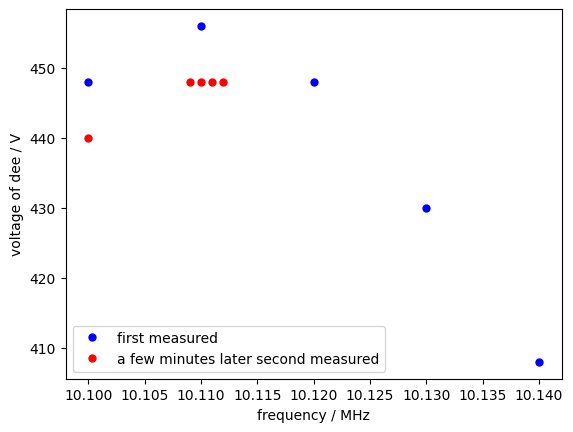

<Figure size 640x480 with 0 Axes>

In [11]:
freq1 = np.array([10.1,10.12,10.13,10.14,10.115])
vol1 = np.array([194,174,164,154,179]) * 2
freq2 = np.array([10.1,10.11,10.12,10.13,10.14,10.111,10.112,10.109,10.110,10.10])
vol2=np.array([224,228,224,215,204,224,224,224,224,220]) * 2
plt.plot(freq1, vol1,'.',markersize=10)
plt.xlabel("frequency / MHz")
plt.ylabel("voltage of dee / V")
plt.figure()

# 前半
plt.plot(freq2[:5], vol2[:5], '.', color='blue', label='first measured',markersize=10)

# 後半
plt.plot(freq2[5:], vol2[5:], '.', color='red',label='a few minutes later second measured',markersize=10)
plt.xlabel("frequency / MHz")
plt.ylabel("voltage of dee / V")
plt.legend()
plt.figure()
